# What are the most demanded skills for the top 3 most popular data roles?

Methodology

Clean-up skill column

Calculate skill count based on job_title_short

Calculate skill percentage

Plot final findings

In [1]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\acer\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# This is the final output we will get after our analysis:-

i) for US location:-

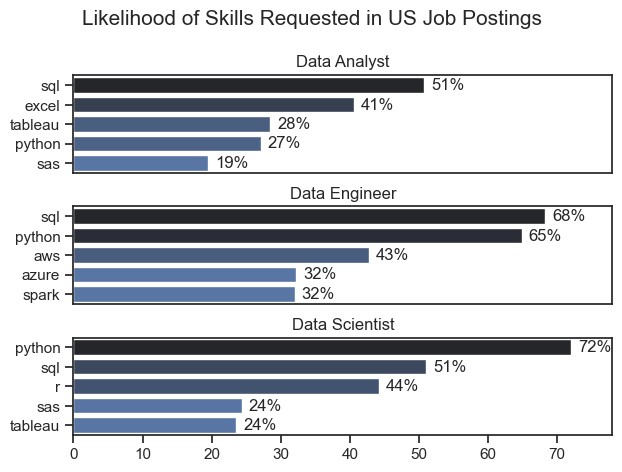

In [104]:
fig, ax = plt.subplots(len(job_titles), 1)


for i, job_title in enumerate(job_titles):
    df_plot = df_us_skills_perc[df_us_skills_perc['job_title_short'] == job_title].head(5)
    sns.barplot(data=df_plot, x='skill_percentage', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].get_legend().remove()
    ax[i].set_xlim(0, 78)

    if i != len(job_titles) - 1:
        ax[i].set_xticks([])
    for n , v in enumerate(df_plot['skill_percentage']):
        ax[i].text(v + 1, n, f'{v:.0f}%', va='center')    
        
fig.suptitle('Likelihood of Skills Requested in US Job Postings', fontsize=15)
fig.tight_layout(h_pad=.8)
plt.show()  

---

for india location:-

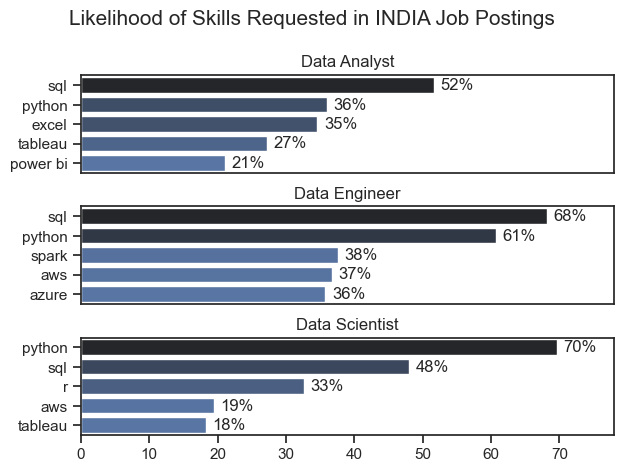

In [103]:
fig, ax = plt.subplots(len(job_titles), 1)


for i, job_title in enumerate(job_titles):
    df_plot = df_ind_skills_perc[df_ind_skills_perc['job_title_short'] == job_title].head(5)
    sns.barplot(data=df_plot, x='skill_percent', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].get_legend().remove()
    ax[i].set_xlim(0, 78)
    # remove the x-axis tick labels for better readability
    if i != len(job_titles) - 1:
        ax[i].set_xticks([])

    # label the percentage on the bars
    for n, v in enumerate(df_plot['skill_percent']):
        ax[i].text(v + 1, n, f'{v:.0f}%', va='center')

fig.suptitle('Likelihood of Skills Requested in INDIA Job Postings', fontsize=15)
fig.tight_layout(h_pad=.8)
plt.show()

# Below is the step by step procress which explains how i get these insights:-

now for us locations:-

In [3]:
df_us = df[df['job_country'] == 'United States']


now for their skills:-

In [4]:
df_us_skills = df_us.explode('job_skills')

df_us_skills[['job_title', 'job_skills']]

,job_title,job_skills
0,Senior Clinical Data Engineer / Principal Clin...,None
3,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,python
3,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,c++
3,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,java
3,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,matlab
...,...,...
785692,Data Scientist- Hybrid Work Location,r
785703,Data Analyst - CRYPTOGRAPHY - Full-time,None
785705,Expert Business Data Analyst - Now Hiring,sql
785705,Expert Business Data Analyst - Now Hiring,python


In [8]:
df_us_skills_count = df_us_skills.groupby(['job_skills', 'job_title_short']).size()
df_us_skills_count

job_skills  job_title_short          
airflow     Business Analyst               38
            Cloud Engineer                 27
            Data Analyst                  387
            Data Engineer                4716
            Data Scientist               1166
                                         ... 
zoom        Machine Learning Engineer       5
            Senior Data Analyst            50
            Senior Data Engineer           30
            Senior Data Scientist          25
            Software Engineer              16
Length: 1870, dtype: int64

In [9]:
type(df_us_skills_count)

pandas.core.series.Series

now we need to convert that series into dataframe and so we can also do it by reset index and also by this we will rename the count coloumn

In [ ]:
df_us_skills_count = df_us_skills_count.reset_index(name='skill_count')
# ran multiple times so we get error

TypeError: DataFrame.reset_index() got an unexpected keyword argument 'name'

now we sort them

In [18]:
df_us_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)

now for top 3 roles

In [19]:
job_titles = df_us_skills_count['job_title_short'].unique().tolist()

job_titles = sorted(job_titles[:3])
# sorted gives us alphabetic order

job_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

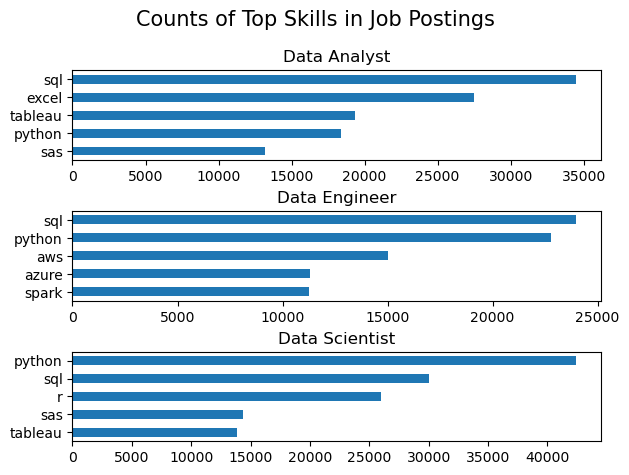

In [43]:
fig, ax = plt.subplots(len(job_titles) , 1)


for i, job_title in enumerate(job_titles):
 df_plot = df_us_skills_count[df_us_skills_count['job_title_short'] == job_title].head(5)
 df_plot.plot(kind='barh', x='job_skills', y='skill_count', ax=ax[i], title=job_title)
 ax [i].invert_yaxis ()
 ax[i].set_ylabel('')
 ax[i].legend().set_visible(False)

fig. suptitle('Counts of Top Skills in Job Postings', fontsize=15)
fig.tight_layout(h_pad=0.5) # fix the overlap
plt.show()


now we need to convert the counts into percentages

% of skill in a job posting = (skill count in job postings) / (total count of job postings)

see we can also use reset index to make a series into a data frame

In [28]:
df_us_job_title_count= df_us['job_title_short'].value_counts().reset_index(name='jobs_total')

now lets merge with df_skills_count

In [34]:
pd.merge(df_us_skills_count, df_us_job_title_count , how='left' , on='job_title_short')
# we are doing a left join of df_us_skills, df_us_job_title_count on job title short 

,job_skills,job_title_short,skill_count,jobs_total
0,python,Data Scientist,42379,58830
1,sql,Data Analyst,34452,67816
2,sql,Data Scientist,30034,58830
3,excel,Data Analyst,27519,67816
4,r,Data Scientist,26022,58830
...,...,...,...,...
1865,vue.js,Business Analyst,1,7382
1866,arch,Business Analyst,1,7382
1867,asana,Machine Learning Engineer,1,921
1868,no-sql,Machine Learning Engineer,1,921


In [38]:
df_us_skills_perc= pd.merge(df_us_skills_count, df_us_job_title_count , how='left' , on='job_title_short')
# now here inside this we make a new coloumn of skills percentage

df_us_skills_perc['skill_percentage'] = 100* df_us_skills_perc['skill_count'] / df_us_skills_perc['jobs_total']

df_us_skills_perc

,job_skills,job_title_short,skill_count,jobs_total,skill_percentage
0,python,Data Scientist,42379,58830,72.036376
1,sql,Data Analyst,34452,67816,50.802171
2,sql,Data Scientist,30034,58830,51.052184
3,excel,Data Analyst,27519,67816,40.578919
4,r,Data Scientist,26022,58830,44.232534
...,...,...,...,...,...
1865,vue.js,Business Analyst,1,7382,0.013546
1866,arch,Business Analyst,1,7382,0.013546
1867,asana,Machine Learning Engineer,1,921,0.108578
1868,no-sql,Machine Learning Engineer,1,921,0.108578


now we need to plot this in same way we ploted the previous one

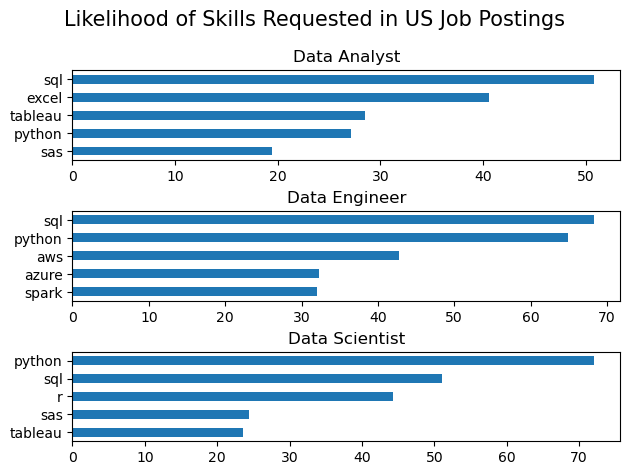

In [45]:
fig, ax = plt.subplots(len(job_titles) , 1)


for i, job_title in enumerate(job_titles):
 df_plot = df_us_skills_perc[df_us_skills_perc['job_title_short'] == job_title].head(5)
 df_plot.plot(kind='barh', x='job_skills', y='skill_percentage', ax=ax[i], title=job_title)
 ax [i].invert_yaxis ()
 ax[i].set_ylabel('')
 ax[i].legend().set_visible(False)


fig. suptitle('Likelihood of Skills Requested in US Job Postings', fontsize=15)
fig.tight_layout(h_pad=0.5) # fix the overlap
plt.show()


after some cleanup

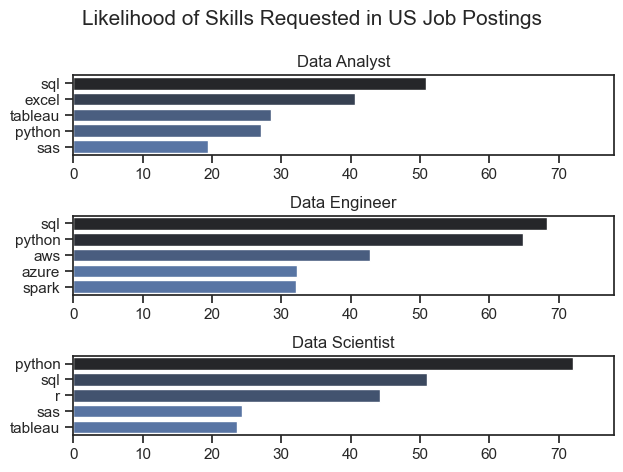

In [ ]:
fig, ax = plt.subplots(len(job_titles), 1)


for i, job_title in enumerate(job_titles):
    df_plot = df_us_skills_perc[df_us_skills_perc['job_title_short'] == job_title].head(5)
    sns.barplot(data=df_plot, x='skill_percentage', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].get_legend().remove()
    ax[i].set_xlim(0, 78)

    
fig.suptitle('Likelihood of Skills Requested in US Job Postings', fontsize=15)
fig.tight_layout(h_pad=.8)
plt.show()   

like in scatter plots we did naming here also we do but using loops 
we run loop inside the existing loop only

for n, v enumerate()
ax[i].text(v , n, v )

inside that text we need to provide na x and y values so x is v and y is n  then on x,y i need to plot v value na so another v 
n is index v is value and as we want to return index we used enumerate

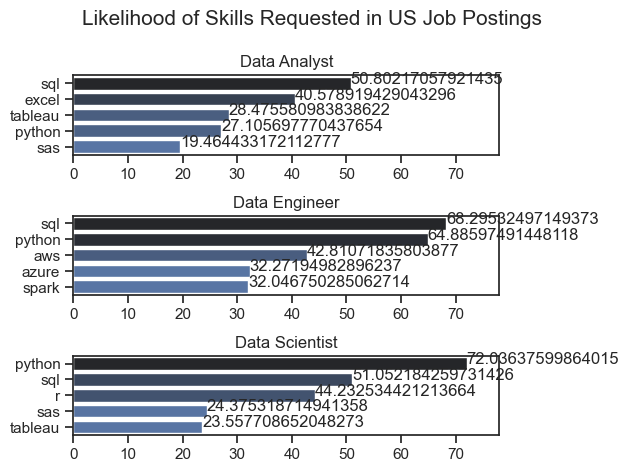

In [61]:
fig, ax = plt.subplots(len(job_titles), 1)


for i, job_title in enumerate(job_titles):
    df_plot = df_us_skills_perc[df_us_skills_perc['job_title_short'] == job_title].head(5)
    sns.barplot(data=df_plot, x='skill_percentage', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].get_legend().remove()
    ax[i].set_xlim(0, 78)
    
    for n , v in enumerate(df_plot['skill_percentage']):
        ax[i].text(v ,n , v)
    
fig.suptitle('Likelihood of Skills Requested in US Job Postings', fontsize=15)
fig.tight_layout(h_pad=.8)
plt.show()  

now to get these values in centre i will have to do:-



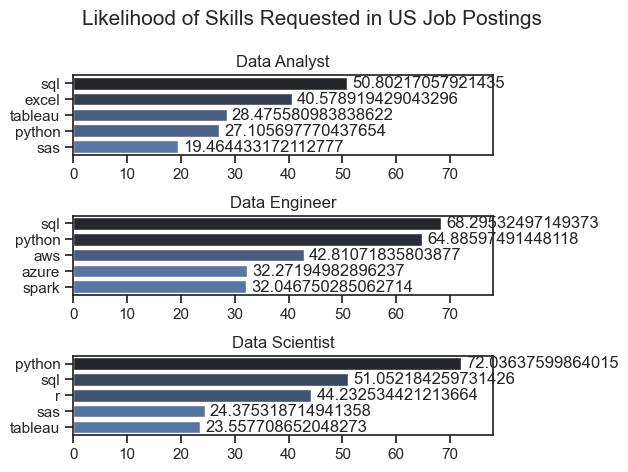

In [64]:
fig, ax = plt.subplots(len(job_titles), 1)


for i, job_title in enumerate(job_titles):
    df_plot = df_us_skills_perc[df_us_skills_perc['job_title_short'] == job_title].head(5)
    sns.barplot(data=df_plot, x='skill_percentage', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].get_legend().remove()
    ax[i].set_xlim(0, 78)
    
    for n , v in enumerate(df_plot['skill_percentage']):
        ax[i].text(v + 1 ,n , v , va='center' )
    
fig.suptitle('Likelihood of Skills Requested in US Job Postings', fontsize=15)
fig.tight_layout(h_pad=.8)
plt.show()  

now for  % cleanup we use f string and also string formating to get 0 decimal places.. 

we could also do ax[i].text(v+1, n, f'{int(v)}', va='center') but this will not give correct % so string formating it is


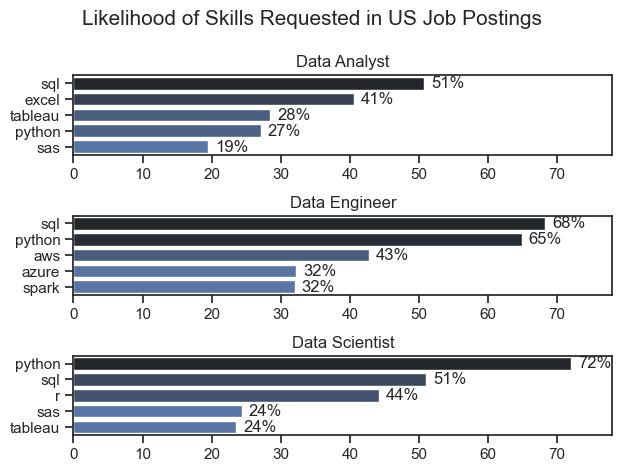

In [65]:
fig, ax = plt.subplots(len(job_titles), 1)


for i, job_title in enumerate(job_titles):
    df_plot = df_us_skills_perc[df_us_skills_perc['job_title_short'] == job_title].head(5)
    sns.barplot(data=df_plot, x='skill_percentage', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].get_legend().remove()
    ax[i].set_xlim(0, 78)
    
    for n , v in enumerate(df_plot['skill_percentage']):
        ax[i].text(v + 1, n, f'{v:.0f}%', va='center')    
        
fig.suptitle('Likelihood of Skills Requested in US Job Postings', fontsize=15)
fig.tight_layout(h_pad=.8)
plt.show()  

but here we see that for all graphs x axis is same so we do 

    if i != len(job_titles) - 1:
        ax[i].set_xticks([])
        # remove the x-axis tick labels for better readability for first two only.. if we didnt use if then for all three x axis would go

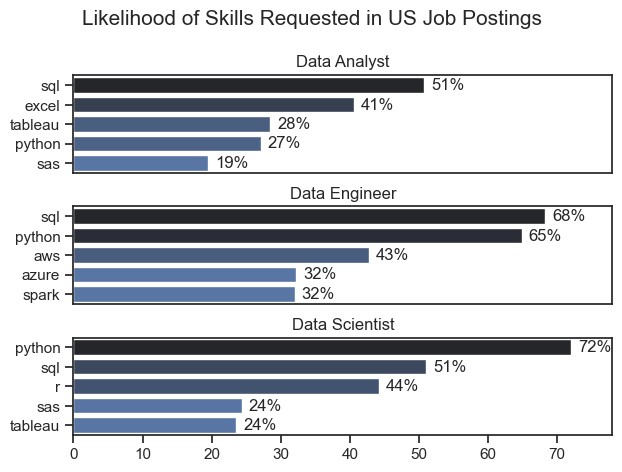

In [ ]:
fig, ax = plt.subplots(len(job_titles), 1)


for i, job_title in enumerate(job_titles):
    df_plot = df_us_skills_perc[df_us_skills_perc['job_title_short'] == job_title].head(5)
    sns.barplot(data=df_plot, x='skill_percentage', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].get_legend().remove()
    ax[i].set_xlim(0, 78)

    if i != len(job_titles) - 1:
        ax[i].set_xticks([])
    for n , v in enumerate(df_plot['skill_percentage']):
        ax[i].text(v + 1, n, f'{v:.0f}%', va='center')    
        
fig.suptitle('Likelihood of Skills Requested in US Job Postings', fontsize=15)
fig.tight_layout(h_pad=.8)
plt.show()  

---

# for india:-

In [89]:
df_ind = df[df['job_country'] == 'India']

df_ind_skills = df_ind.explode('job_skills')

In [ ]:
df_ind_skills_count = (
    df_ind_skills
    .groupby(['job_title_short', 'job_skills'])
    .size()
    .reset_index(name='skill_count')
    .sort_values(by='skill_count', ascending=False)
)

# we can do like this also

In [92]:
df_ind_skills_count

,job_title_short,job_skills,skill_count
637,Data Engineer,sql,12993
603,Data Engineer,python,11568
807,Data Scientist,python,9248
632,Data Engineer,spark,7157
480,Data Engineer,aws,6993
...,...,...,...
25,Business Analyst,dart,1
27,Business Analyst,datarobot,1
30,Business Analyst,django,1
32,Business Analyst,drupal,1


In [93]:
job_titles = df_ind_skills_count['job_title_short'].unique().tolist()

job_titles = sorted(job_titles[:3])

job_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

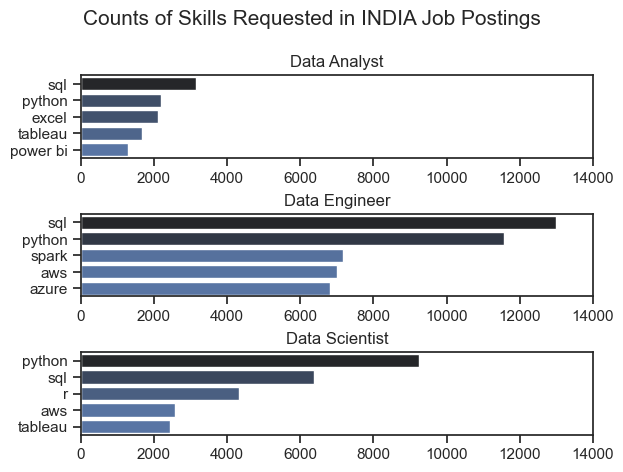

In [97]:
fig, ax = plt.subplots(len(job_titles), 1)

sns.set_theme(style='ticks')

for i, job_title in enumerate(job_titles):
    df_plot = df_ind_skills_count[df_ind_skills_count['job_title_short'] == job_title].head(5)[::-1]
    sns.barplot(data=df_plot, x='skill_count', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    ax[i].set_title(job_title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].get_legend().remove()
    ax[i].set_xlim(0, 14000) # make the scales the same

fig.suptitle('Counts of Skills Requested in INDIA Job Postings', fontsize=15)
fig.tight_layout(h_pad=0.5) # fix the overlap
plt.show()

In [98]:
# Use original df to get the count of job titles
df_job_title_count = df_ind['job_title_short'].value_counts().reset_index(name='jobs_total')

df_job_title_count

,job_title_short,jobs_total
0,Data Engineer,19062
1,Data Scientist,13279
2,Data Analyst,6121
3,Senior Data Engineer,4353
4,Senior Data Scientist,2486
5,Business Analyst,1887
6,Software Engineer,1795
7,Senior Data Analyst,1083
8,Machine Learning Engineer,671
9,Cloud Engineer,351


again merge this with skill count

In [100]:
df_ind_skills_perc = pd.merge(df_ind_skills_count, df_job_title_count, on='job_title_short', how='left')

df_ind_skills_perc['skill_percent'] = (df_skills_perc['skill_count'] / df_skills_perc['jobs_total']) * 100

df_ind_skills_perc

,job_title_short,job_skills,skill_count,jobs_total,skill_percent
0,Data Engineer,sql,12993,19062,68.161788
1,Data Engineer,python,11568,19062,60.686182
2,Data Scientist,python,9248,13279,69.643798
3,Data Engineer,spark,7157,19062,37.545903
4,Data Engineer,aws,6993,19062,36.685552
...,...,...,...,...,...
1684,Business Analyst,dart,1,1887,0.052994
1685,Business Analyst,datarobot,1,1887,0.052994
1686,Business Analyst,django,1,1887,0.052994
1687,Business Analyst,drupal,1,1887,0.052994


now finally

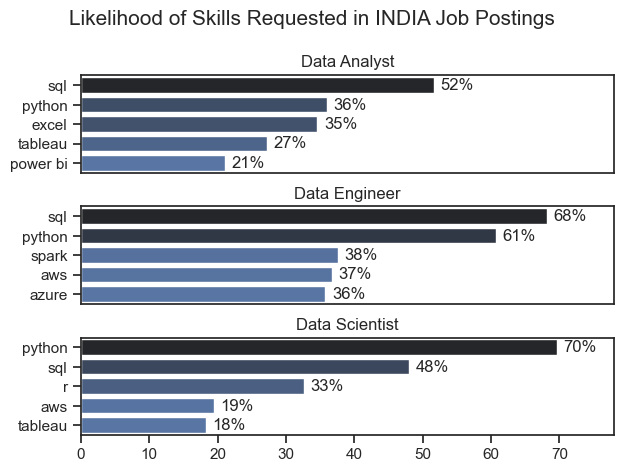

In [102]:
fig, ax = plt.subplots(len(job_titles), 1)


for i, job_title in enumerate(job_titles):
    df_plot = df_ind_skills_perc[df_ind_skills_perc['job_title_short'] == job_title].head(5)
    sns.barplot(data=df_plot, x='skill_percent', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].get_legend().remove()
    ax[i].set_xlim(0, 78)
    # remove the x-axis tick labels for better readability
    if i != len(job_titles) - 1:
        ax[i].set_xticks([])

    # label the percentage on the bars
    for n, v in enumerate(df_plot['skill_percent']):
        ax[i].text(v + 1, n, f'{v:.0f}%', va='center')

fig.suptitle('Likelihood of Skills Requested in INDIA Job Postings', fontsize=15)
fig.tight_layout(h_pad=.8)
plt.show()

---